# Dataset Summary
The CIFAR-10 dataset consists of 60000 32x32 colour images in 10 classes, with 6000 images per class. There are 50000 training images and 10000 test images. The dataset is divided into five training batches and one test batch, each with 10000 images. The test batch contains exactly 1000 randomly-selected images from each class. The training batches contain the remaining images in random order, but some training batches may contain more images from one class than another. Between them, the training batches contain exactly 5000 images from each class.



## Packages & Imports

In [1]:
!pip install datasets

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torchvision import transforms
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np
from sklearn.metrics import classification_report
import cv2
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.manifold import TSNE

## Loading the Dataset

In [3]:
from datasets import load_dataset
dataset = load_dataset("uoft-cs/cifar10")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Access to the secret `HF_TOKEN` has not been granted on this notebook.
You will not be requested again.
Please restart the session if you want to be prompted again.
  warnings.warn(


README.md:   0%|          | 0.00/5.16k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/120M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/23.9M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

## Data Inspection

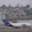

In [4]:
# Training split
train_data = dataset['train']

# First image & label
first_image = train_data[0]['img']
first_label = train_data[0]['label']

first_image

### Displaying features/classes

In [5]:
print(train_data.features)

{'img': Image(mode=None, decode=True), 'label': ClassLabel(names=['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck'])}


The label feature is of ClassLabel type, which has a names attribute to get all class labels.

In [6]:
class_labels = train_data.features['label'].names
print("Class Labels:", class_labels)

Class Labels: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


So, the classes we are working with are:
airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck

### Number of Images per Class

In [7]:
train_labels = [item['label'] for item in train_data]
label_counts = pd.Series(train_labels).value_counts().sort_index()

label_counts.index = label_counts.index.map(lambda x: class_labels[x])

print("Distribution of images per class (Training Set):")
display(label_counts)

Distribution of images per class (Training Set):


,count
airplane,5000
automobile,5000
bird,5000
cat,5000
deer,5000
dog,5000
frog,5000
horse,5000
ship,5000
truck,5000


### Check for Unclassified Images
Just verifying by checking for any None or out-of-bound label values.

In [8]:
unclassified_count = sum(1 for item in train_data if item['label'] is None or item['label'] not in range(len(class_labels)))

if unclassified_count == 0:
    print("No unclassified images")
else:
    print(f"{unclassified_count} unclassified images")

No unclassified images


### Image Pixel Dimensions
Checking the size of the images

In [9]:
print(f"All images are {first_image.size[0]}x{first_image.size[1]} pixels.")

All images are 32x32 pixels.


## Data Visualization
Plotting a few images from the training set to see what they look like.

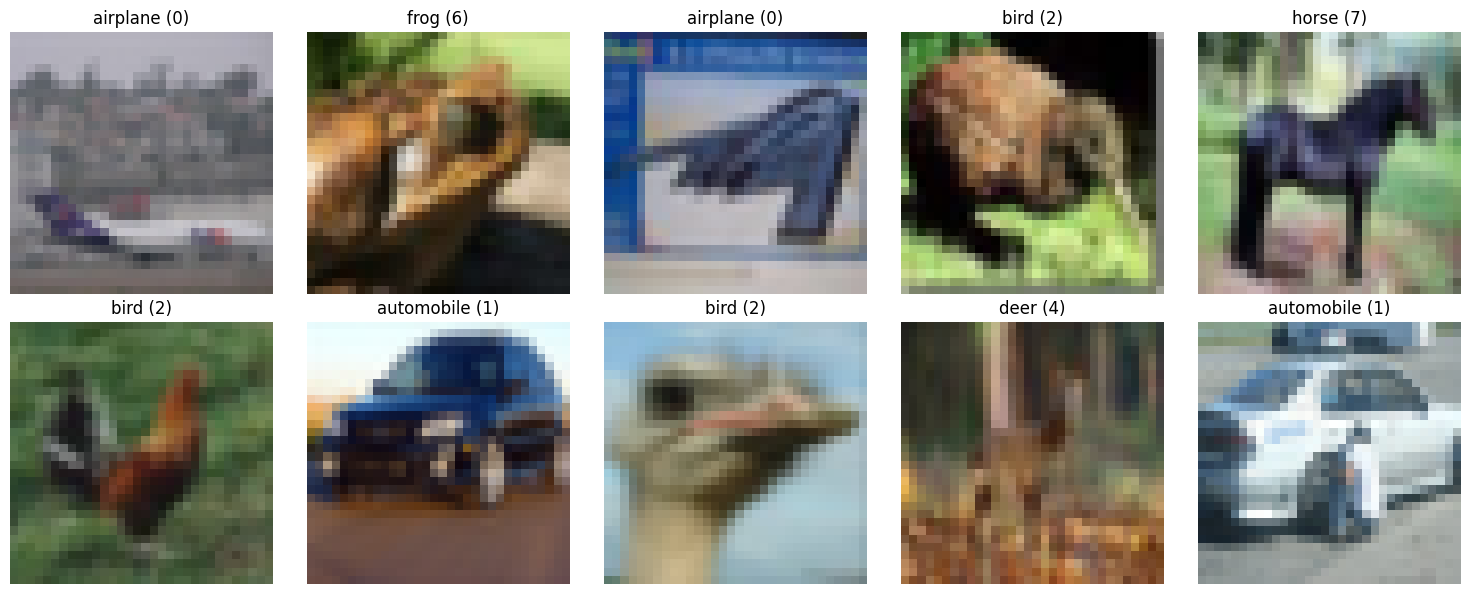

In [10]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i in range(10):
    img = train_data[i]['img']
    label_idx = train_data[i]['label']
    label_name = class_labels[label_idx]

    axes[i].imshow(img)
    axes[i].set_title(f"{label_name} ({label_idx})")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

## Data Splitting

Plan: Split off 10% of the training set and allocate it to the validation set. Then, convert PIL images into PyTorch tensors and normalize the pixel values for the training, validation, and test set sequentially. Then, we can augment the training set for better generalization.

In [11]:
# 90% training 10% validation
split_dataset = train_data.train_test_split(test_size=0.1, seed=42)

train_data = split_dataset['train']
val_data = split_dataset['test']  # train_test_split names the test split 'test' by default

print(f"Training set size: {len(train_data)}")
print(f"Validation set size: {len(val_data)}")


Training set size: 45000
Validation set size: 5000


### Checking the class distribution for the Validation Set

- The natural variation is normal and won't negatively impact the model training.

In [12]:
val_labels = [item['label'] for item in val_data]
label_counts = pd.Series(val_labels).value_counts().sort_index()

label_counts.index = label_counts.index.map(lambda x: class_labels[x])

print("Distribution of images per class (Validation Set):")
display(label_counts)

Distribution of images per class (Validation Set):


,count
airplane,490
automobile,487
bird,463
cat,447
deer,513
dog,517
frog,526
horse,539
ship,502
truck,516


## Data Preprocessing
- Need to define transformations to convert the PIL images (python objects from the python image library) into PyTorch tensors and normalize the pixel values.

- Images are represented in arrays of pixel values [0-255] for each color channel (RGB). We need to normalize, or transform the pixel values to a specific range. In practice, images are usually normalized to either [0,1] or [-1,1].

- In our case, we'll normalize [-1,1], or center around zero because if all input features are positive, the gradients during backpropagation are either all positive or all negative, which could cause slower convergence in the optimization.


- Also setting up a DataLoader to better iterate through the dataset in batches during training.

### Data Augmentation
We apply data augmentation (like RandomHorizontalFlip and RandomRotation) only to the training set. We do this to artificially expand our dataset and prevent overfitting, as well as forcing the model to learn generalized features instead of memorizing the exact format of the training images.

We do not augment the validation or test sets because we want to evaluate the model on standard and unmodified images that represent real-world input.

In [13]:
# Base transform for validation and test sets (no augmentation)
val_test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Train transform w/ aggressive data augmentation
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
    transforms.RandomErasing(p=0.5, scale=(0.02, 0.2), ratio=(0.3, 3.3), value=0) # NEW: Random Erasing
])

# Function to apply train transforms to a batch
def preprocess_train(batch):
    batch['pixel_values'] = [train_transform(img) for img in batch['img']]
    return batch

# Function to apply val/test transforms to a batch
def preprocess_val_test(batch):
    batch['pixel_values'] = [val_test_transform(img) for img in batch['img']]
    return batch

- We randomly shuffle the training data. The reason is, while training, the model learns by looking at a batch of images, predicting, finding the loss, and then updating the weights. If we don't shuffle the data, it's possible for it to be ordered by class. If the model sees multiple batches of a single class, it'll adjust it's weights heavily to recognize that class. Then, when the batch changes the class, it'll have to make the heavy update to account for learning the new class, and that process could make it 'forget' the previous class.

- If we shuffle, we introduce images of different classes randomly to the model, and therefore, keep the weight updates stable.

- It's also important to acknowledge that we do not shuffle the validation and test sets. The reason is, when we run data through those sets, the model isn't learning. It's only making predictions based on it's learned weights. Since the weights aren't being updated, the order in which we present the images doesn't change the final statistics.

- We want determinism while evaluation, which makes it easier to go back and trace specific results for specific runs.


In [14]:
# Extract the test set from the original dataset
test_data = dataset['test']

# Apply specific transforms to datasets
train_data.set_transform(preprocess_train)
val_data.set_transform(preprocess_val_test)
test_data.set_transform(preprocess_val_test)

# Make the DataLoaders to batch the data
batch_size = 64

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

print(f"Train Loader: {len(train_loader)} batches")
print(f"Validation Loader: {len(val_loader)} batches")
print(f"Test Loader: {len(test_loader)} batches")

Train Loader: 704 batches
Validation Loader: 79 batches
Test Loader: 157 batches


# Reasoning on architecture of the CNN model

## First convolutional layer

We know CIFAR-10 has 32x32 pixel images, and they're in color RGB.

The first convolutional layer needs to know how many channels of data it'll be receiving as input.

How convolution layers process images:

Pytorch: nn.Conv2d: A module to apply 2D spatial convolutions over multi-channel data.
- The expected parameters are:
  1. in_channels(int): Number of channels in the input (3 for us), since we're using colored images.

  2. out_channels(int): Number of kernels we want the layer to learn. We will go with a 32->64->128 approach, as we want to go from capturing local nuances to larger parts of the images that require a bit of semantic understanding and be able to store all of that information.
  
  3. kernel_size(int/tuple): The dimensions of the sliding window filter. We will use a 3x3 kernel to make sure we're capturing local detail on the already small 32x32 images.

## After the convolutional layer

After a convolutional layer extracts features, we need to process those features before passing them deeper into the network.

1.  Activation Function (ReLU): We apply a non-linear activation function. Convolutions are linear operations. If we only use linear operations, our network would retain a single linear transformation. ReLU replaces all negative pixel values in the feature map with zero, which brings non-linearity.

2.  Pooling Layer (Max Pooling): After activation, apply a pooling layer to downsample the spatial dimensions (height and width) of the image. A MaxPool2d(2, 2) slides a 2x2 window over the feature map and keeps only the maximum value in that window.
    - It halves the image dimensions (from 32x32 to 16x16), which reduces the num. of parameters & computations for the next layers. It also makes the network more generalized to small shifts in the image.

3. Fully Connected Layers: After the convolutional & pooling layers extract the hierarchical features from the input image and reduce the spatial dimensions, the fully connected layers act as a classifier. Before going into the first fully connected layer, the 3D output (channels, height, width) from the last pooling layer needs to be flattened into a 1D vector. This converts the spatial feature maps into a single long vector of features. The purpose of these layers are to take all the features learned by the previous convolutional layers and learn non-linear combinations of these features.

  - Then, the final fully connected layer has an output size equal to the number of classes in the classification problem, which is 10 in our case. Each output unit corresponds to a class,

# CNN Architecture: Custom ResNet-18

## General Principles Applied in the Model
1.  **Skip Connections (`shortcut`)**:
    - The core of Residual Networks. It bypasses one or more layers, adding the original input of a block to its output. This creates an unimpeded path for gradients during backpropagation and solves the degradation problem in deep networks.
2. **nn.Conv2d (Convolutional Layers)**:
    - Used for feature extraction. We adapted the first convolutional layer to a 3x3 kernel (instead of ResNet's standard 7x7) to better preserve the spatial dimensions of the tiny 32x32 CIFAR-10 images without losing too much information early on.
3. **nn.BatchNorm2d (Batch Normalization)**:
    - Normalizes the activations after convolutional layers to stabilize and speed up the training process.
4. **F.relu (ReLU Activation)**:
    - Adds non-linearity to the network.
5. **nn.AdaptiveAvgPool2d (Global Average Pooling)**:
    - Shrinks the final spatial dimensions down to 1x1 per channel, vastly reducing the number of parameters needed in the final fully connected layer and helping prevent overfitting.

In [15]:
class BasicBlock(nn.Module):
    # Expansion is 1 for ResNet-18 and 34 (output channels are same as input channels for a block)
    expansion = 1

    def __init__(self, in_channels, out_channels, stride=1):
        super(BasicBlock, self).__init__()

        # First convolutional layer of the block
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3,
                               stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)

        # Second convolutional layer
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3,
                               stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        # Skip Connection
        self.shortcut = nn.Sequential()

        # If dimensions change or channel size changes,
        # we need a 1x1 convolution to match them up so we can add them later.
        if stride != 1 or in_channels != self.expansion * out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, self.expansion * out_channels, kernel_size=1,
                          stride=stride, bias=False),
                nn.BatchNorm2d(self.expansion * out_channels)
            )

    def forward(self, x):
        # Main Path
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))

        # Adding the skip connection BEFORE the final activation
        out += self.shortcut(x)
        out = F.relu(out)
        return out


class ResNet(nn.Module):
    def __init__(self, block, num_blocks, num_classes=10):
        super(ResNet, self).__init__()
        self.in_channels = 64

        # Initial Layer (Modified for CIFAR-10's 32x32 resolution)
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)

        # ResNet Layers - each containing multiple BasicBlocks
        self.layer1 = self._make_layer(block, 64, num_blocks[0], stride=1)
        self.layer2 = self._make_layer(block, 128, num_blocks[1], stride=2)
        self.layer3 = self._make_layer(block, 256, num_blocks[2], stride=2)
        self.layer4 = self._make_layer(block, 512, num_blocks[3], stride=2)

        # Final Classifier
        self.avg_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512 * block.expansion, num_classes)

    def _make_layer(self, block, out_channels, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        for s in strides:
            layers.append(block(self.in_channels, out_channels, s))
            self.in_channels = out_channels * block.expansion
        return nn.Sequential(*layers)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avg_pool(x)
        x = x.view(x.size(0), -1)  # Flatten
        x = self.fc(x)
        return x

# Helper function to initialize ResNet-18
def ResNet18():
    return ResNet(BasicBlock, [2, 2, 2, 2])

# Instantiate model
model = ResNet18()
print("Replaced original model with ResNet-18 architecture!")
print(model)

Replaced original model with ResNet-18 architecture!
ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (shortcut): Sequential()
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (b

## Loss Function and Optimizer
Before writing the training loop, define the loss function & the optimizer that updates the model parameters.

- CrossEntropyLoss applies softmax to the outputs and calculates the negative log likelihood.


In [16]:
epochs = 100

lossFunc = nn.CrossEntropyLoss()

# Switched to SGD with momentum and weight decay (L2 Regularization)
optimizer = optim.SGD(model.parameters(), lr=0.05, momentum=0.9, weight_decay=1e-4)

# Switched to Cosine Annealing Learning Rate Scheduler
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

## Device Config
Checking if CUDA is available

In [17]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model.to(device)

Using device: cuda


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (shortcut): Sequential()
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=

## Training Loop

In [18]:
def custom_collate(batch):
    return {
        'pixel_values': torch.stack([item['pixel_values'] for item in batch]),
        'label': torch.tensor([item['label'] for item in batch])
    }

train_loader = DataLoader(train_loader.dataset, batch_size=train_loader.batch_size, shuffle=True, collate_fn=custom_collate)
val_loader = DataLoader(val_loader.dataset, batch_size=val_loader.batch_size, shuffle=False, collate_fn=custom_collate)

train_losses = []
val_losses = []
val_accuracies = []

for epoch in range(epochs):
    # Training
    model.train()
    running_loss = 0.0

    for batch in train_loader:
        # Get inputs and labels from the batch
        inputs = batch['pixel_values'].to(device)
        labels = batch['label'].to(device)

        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(inputs)
        loss = lossFunc(outputs, labels)

        # Backward pass
        loss.backward()

        # Update weights
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)

    epoch_train_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_train_loss)

    # Validation
    model.eval() # evaluation mode
    running_val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad(): # Disable gradient calculation for validation
        for batch in val_loader:
            inputs = batch['pixel_values'].to(device)
            labels = batch['label'].to(device)

            outputs = model(inputs)
            loss = lossFunc(outputs, labels)
            running_val_loss += loss.item() * inputs.size(0)

            # Find accuracy
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_val_loss = running_val_loss / len(val_loader.dataset)
    val_losses.append(epoch_val_loss)
    val_accuracy = 100 * correct / total
    val_accuracies.append(val_accuracy)

    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | Val Accuracy: {val_accuracy:.2f}% | LR: {current_lr:.6f}")

    # Step the scheduler (Cosine Annealing does not need the val_accuracy passed to it)
    scheduler.step()

print("\nDone")

Epoch 1/100 | Train Loss: 1.8032 | Val Loss: 1.4740 | Val Accuracy: 46.78% | LR: 0.050000
Epoch 2/100 | Train Loss: 1.4114 | Val Loss: 1.1522 | Val Accuracy: 59.28% | LR: 0.049988
Epoch 3/100 | Train Loss: 1.2007 | Val Loss: 1.0224 | Val Accuracy: 65.42% | LR: 0.049951
Epoch 4/100 | Train Loss: 1.0515 | Val Loss: 0.9426 | Val Accuracy: 67.18% | LR: 0.049889
Epoch 5/100 | Train Loss: 0.9539 | Val Loss: 0.8766 | Val Accuracy: 70.82% | LR: 0.049803
Epoch 6/100 | Train Loss: 0.8652 | Val Loss: 0.7229 | Val Accuracy: 75.44% | LR: 0.049692
Epoch 7/100 | Train Loss: 0.7914 | Val Loss: 0.7042 | Val Accuracy: 75.82% | LR: 0.049557
Epoch 8/100 | Train Loss: 0.7180 | Val Loss: 0.6335 | Val Accuracy: 78.16% | LR: 0.049398
Epoch 9/100 | Train Loss: 0.6731 | Val Loss: 0.6870 | Val Accuracy: 77.50% | LR: 0.049215
Epoch 10/100 | Train Loss: 0.6341 | Val Loss: 0.5667 | Val Accuracy: 80.76% | LR: 0.049007
Epoch 11/100 | Train Loss: 0.6001 | Val Loss: 0.5699 | Val Accuracy: 80.70% | LR: 0.048776
Epoch 12

## Training Visualization
Plot the training and validation losses, and validation accuracy.

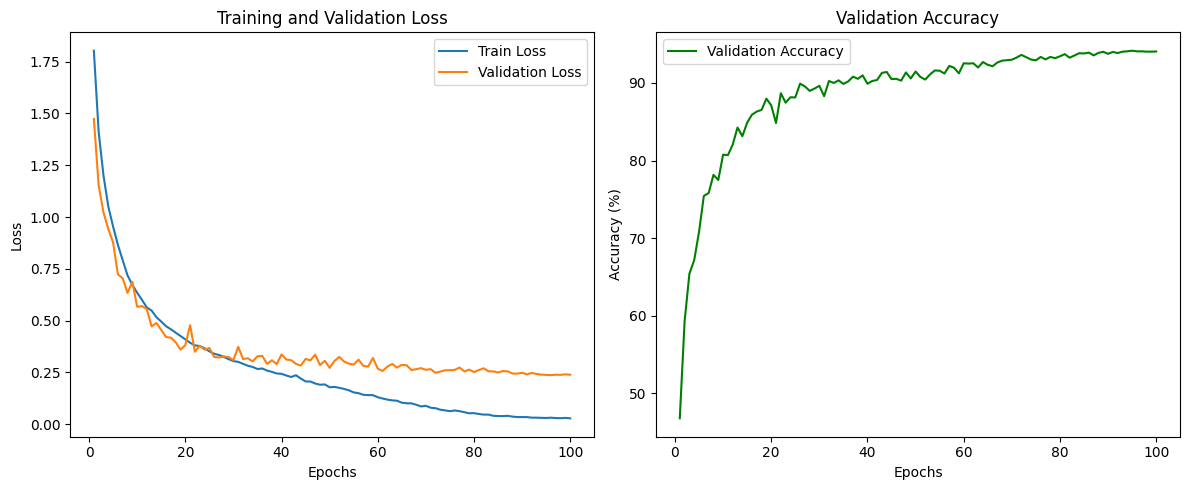

In [19]:
plt.figure(figsize=(12, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(range(1, epochs + 1), train_losses, label='Train Loss')
plt.plot(range(1, epochs + 1), val_losses, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(range(1, epochs + 1), val_accuracies, label='Validation Accuracy', color='green')
plt.title('Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.tight_layout()
plt.show()

## Final Evaluation on Test Set


Final Test Set Results:
Test Loss: 0.2374
Test Accuracy: 94.29%



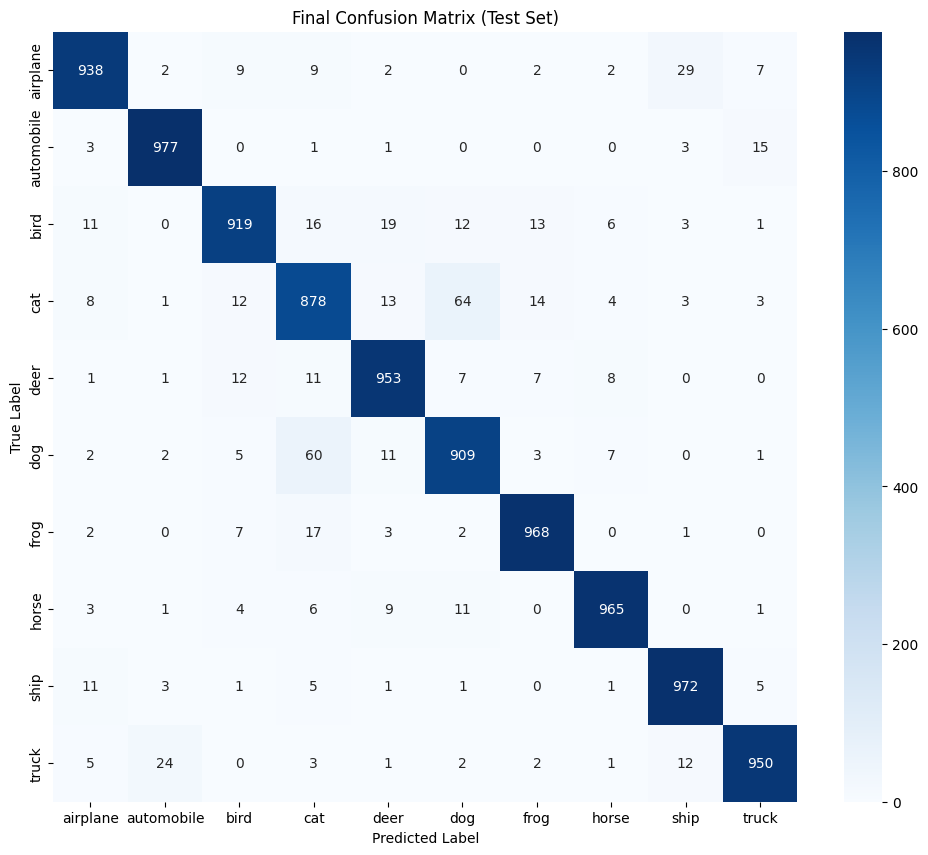

In [20]:
test_loader = DataLoader(test_loader.dataset, batch_size=test_loader.batch_size, shuffle=False, collate_fn=custom_collate)

# Evaluation mode
model.eval()

running_test_loss = 0.0
correct = 0
total = 0

# To store all predictions and true labels for the confusion matrix
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        inputs = batch['pixel_values'].to(device)
        labels = batch['label'].to(device)

        outputs = model(inputs)
        loss = lossFunc(outputs, labels)
        running_test_loss += loss.item() * inputs.size(0)

        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        # Store predictions and labels
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Calculate final metrics
test_loss = running_test_loss / len(test_loader.dataset)
test_accuracy = 100 * correct / total

print(f"\nFinal Test Set Results:")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.2f}%\n")

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Final Confusion Matrix (Test Set)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


### Detailed Classification Metrics
Using the predictions collected during the test evaluation to generate a comprehensive classification report.

In [21]:
report = classification_report(all_labels, all_preds, target_names=class_labels)
print("Classification Report:\n")
print(report)

Classification Report:

              precision    recall  f1-score   support

    airplane       0.95      0.94      0.95      1000
  automobile       0.97      0.98      0.97      1000
        bird       0.95      0.92      0.93      1000
         cat       0.87      0.88      0.88      1000
        deer       0.94      0.95      0.95      1000
         dog       0.90      0.91      0.91      1000
        frog       0.96      0.97      0.96      1000
       horse       0.97      0.96      0.97      1000
        ship       0.95      0.97      0.96      1000
       truck       0.97      0.95      0.96      1000

    accuracy                           0.94     10000
   macro avg       0.94      0.94      0.94     10000
weighted avg       0.94      0.94      0.94     10000



### Visualizing Classification Metrics
Here is a heatmap representation of the precision, recall, and f1-score for each class.

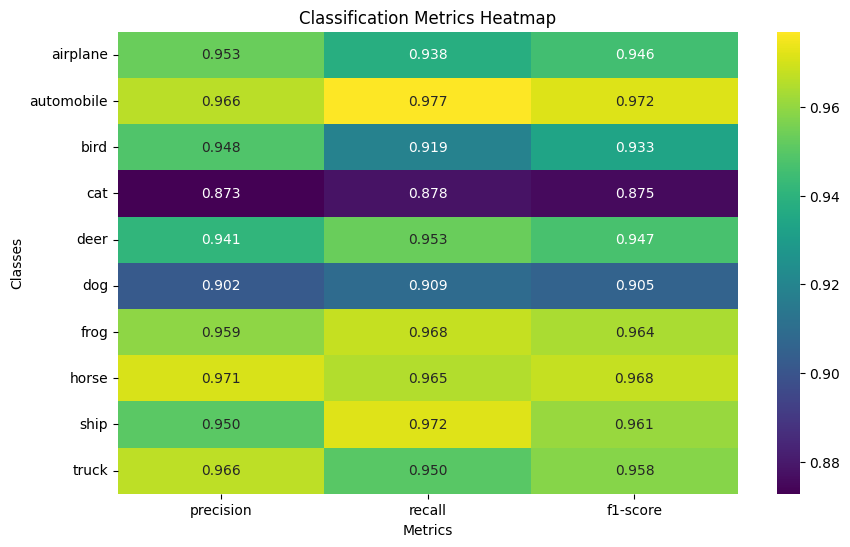

In [22]:
# Get the classification report as a dictionary
report_dict = classification_report(all_labels, all_preds, target_names=class_labels, output_dict=True)

# Convert to a DataFrame, excluding 'support' and overall metrics for a clean heatmap
report_df = pd.DataFrame(report_dict).iloc[:-1, :10].T

plt.figure(figsize=(10, 6))
sns.heatmap(report_df, annot=True, cmap='viridis', fmt='.3f')
plt.title('Classification Metrics Heatmap')
plt.xlabel('Metrics')
plt.ylabel('Classes')
plt.show()

# Error Analysis

To better understand our model's performance, we need to look beyond aggregate metrics and examine specific instances where the model failed. This involves identifying misclassified images and visualizing them to spot patterns.

In [23]:
# 1. Identify misclassified instances
preds_np = np.array(all_preds)
labels_np = np.array(all_labels)
misclassified_indices = np.where(preds_np != labels_np)[0]

print(f"Total misclassified images: {len(misclassified_indices)} out of {len(all_labels)} ({(len(misclassified_indices)/len(all_labels))*100:.2f}% error rate)")

# 2. Extract samples for visualization
num_samples = 15
sample_indices = misclassified_indices[:num_samples]

misclassified_samples = []
for idx in sample_indices:
    idx = int(idx)
    # Access the raw image from the test_data using the original index
    img = test_data[idx]['img']
    true_label = class_labels[labels_np[idx]]
    pred_label = class_labels[preds_np[idx]]

    misclassified_samples.append({
        'image': img,
        'true': true_label,
        'pred': pred_label
    })

Total misclassified images: 571 out of 10000 (5.71% error rate)


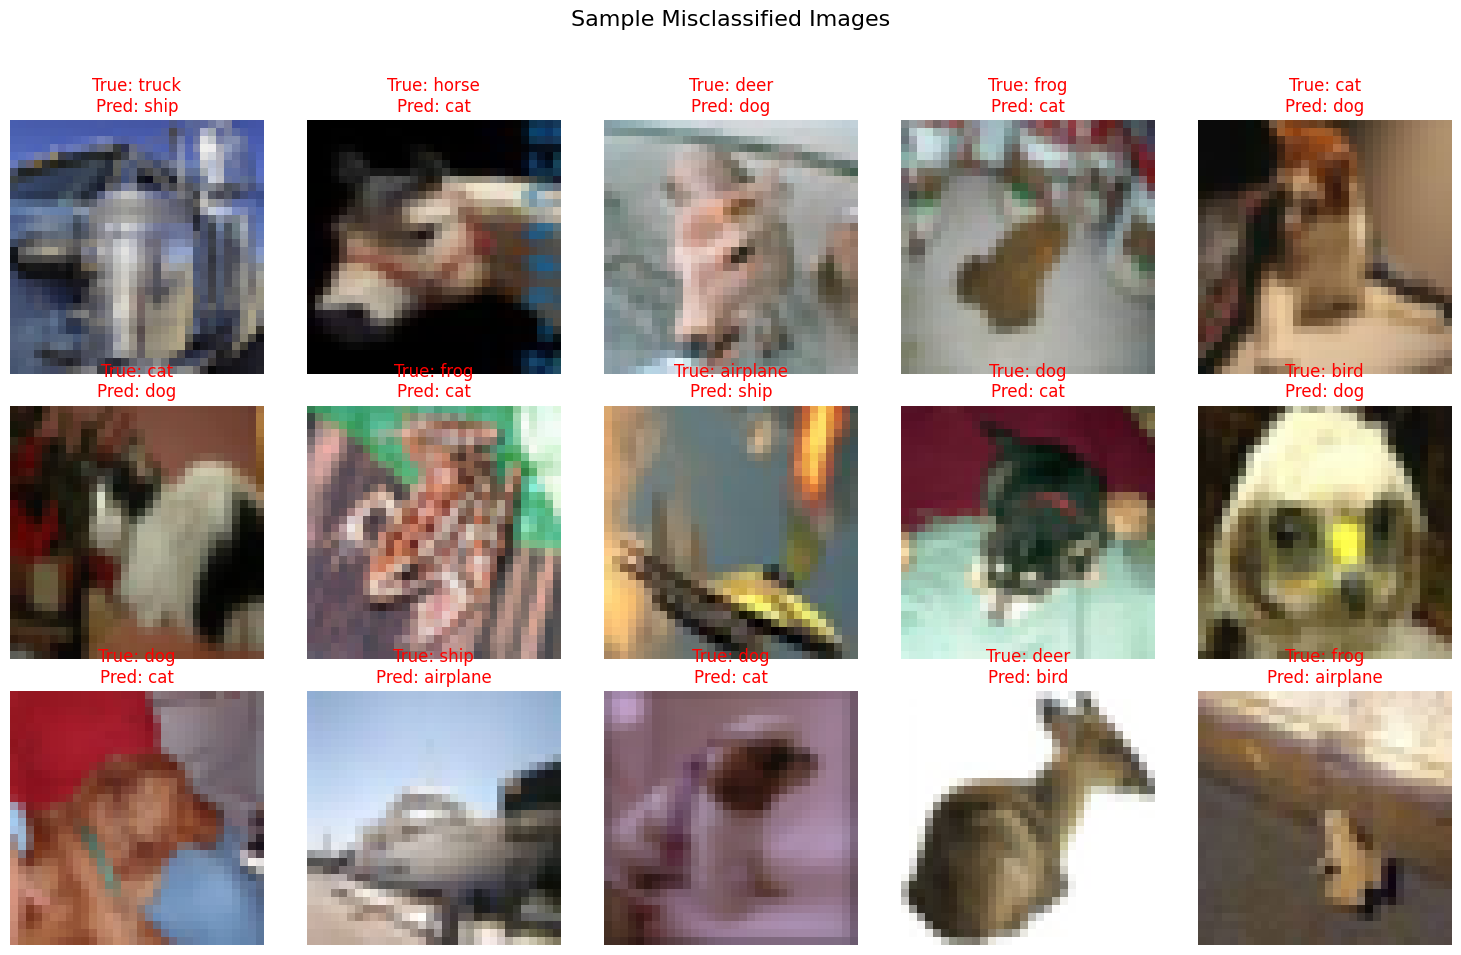

In [24]:
# 3. Visualize the Misclassification Grid
plt.figure(figsize=(15, 10))
for i, sample in enumerate(misclassified_samples):
    plt.subplot(3, 5, i + 1)
    plt.imshow(sample['image'])
    plt.title(f"True: {sample['true']}\nPred: {sample['pred']}", color='red' if sample['true'] != sample['pred'] else 'black')
    plt.axis('off')

plt.suptitle('Sample Misclassified Images', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Model Interpretability: Grad-CAM

To understand why our ResNet-18 model makes certain decisions, we can use **Grad-CAM** (Gradient-weighted Class Activation Mapping). Grad-CAM uses the gradients of any target concept (like the 'dog' class) flowing into the final convolutional layer to produce a coarse localization map highlighting the important regions in the image for predicting that concept.

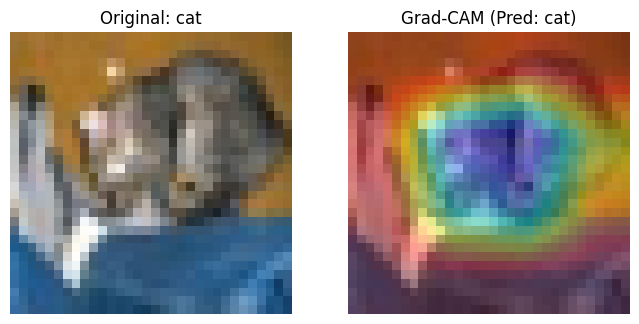

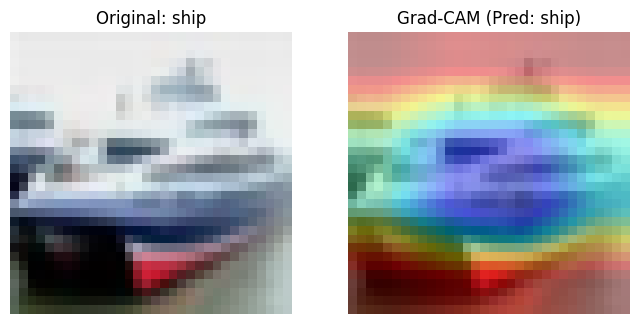

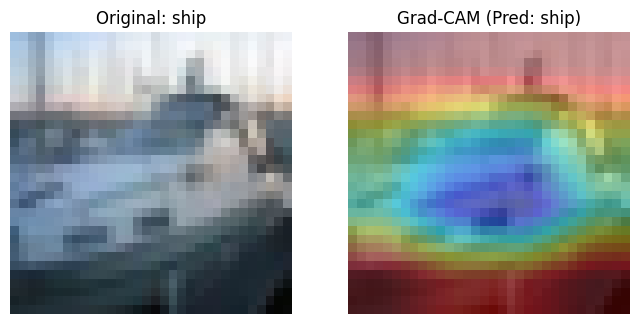

In [25]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        self.hook_layers()

    def hook_layers(self):
        def forward_hook(module, input, output):
            self.activations = output
        def backward_hook(module, grad_input, grad_output):
            self.gradients = grad_output[0]

        self.target_layer.register_forward_hook(forward_hook)
        self.target_layer.register_full_backward_hook(backward_hook)

    def generate_heatmap(self, input_tensor, class_idx):
        self.model.zero_grad()
        output = self.model(input_tensor)
        loss = output[0, class_idx]
        loss.backward()

        # Pool the gradients across the channels
        weights = torch.mean(self.gradients, dim=(2, 3), keepdim=True)
        # Weigh the activations by the gradients
        heatmap = torch.sum(weights * self.activations, dim=1).squeeze()
        # ReLU on the heatmap
        heatmap = np.maximum(heatmap.cpu().detach().numpy(), 0)
        # Normalize
        heatmap /= (np.max(heatmap) + 1e-10)
        return heatmap

def visualize_gradcam(model, dataset, idx, class_labels, device):
    model.eval()
    # Use the last convolutional layer (layer4, block 1, conv2)
    target_layer = model.layer4[1].conv2
    cam = GradCAM(model, target_layer)

    # Prepare input
    data_item = dataset[idx]
    input_tensor = preprocess_val_test({'img': [data_item['img']]})['pixel_values'][0].unsqueeze(0).to(device)
    true_label = data_item['label']

    # Get prediction
    output = model(input_tensor)
    pred_label = torch.argmax(output, dim=1).item()

    # Generate heatmap for the predicted class
    heatmap = cam.generate_heatmap(input_tensor, pred_label)

    # Process original image for overlay
    img = np.array(data_item['img'])
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    superimposed_img = cv2.addWeighted(img, 0.6, heatmap, 0.4, 0)

    # Display
    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title(f"Original: {class_labels[true_label]}")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(superimposed_img)
    plt.title(f"Grad-CAM (Pred: {class_labels[pred_label]})")
    plt.axis('off')
    plt.show()

# Visualize on a few samples from the test set
for i in range(3):
    visualize_gradcam(model, test_data, i, class_labels, device)

## Saving and Loading the Model

In [26]:
model_save_path = 'cifar10_model.pth'

torch.save(model.state_dict(), model_save_path)
print(f"Model weights saved to {model_save_path}")

'''
# If needed to load the model back in without retraining:
# 1. Instantiate the model architecture
loaded_model = CIFAR10Model()

# 2. Load the saved weights into the model
loaded_model.load_state_dict(torch.load(model_save_path))

# 3. Move it to the correct device (GPU/CPU)
loaded_model.to(device)
loaded_model.eval() # Set to evaluation mode
'''

Model weights saved to cifar10_model.pth


'\n# If needed to load the model back in without retraining:\n# 1. Instantiate the model architecture\nloaded_model = CIFAR10Model()\n\n# 2. Load the saved weights into the model\nloaded_model.load_state_dict(torch.load(model_save_path))\n\n# 3. Move it to the correct device (GPU/CPU)\nloaded_model.to(device)\nloaded_model.eval() # Set to evaluation mode\n'

## ROC Curves and AUC (Area Under the Curve)

To further evaluate our classifier, we can look at the Receiver Operating Characteristic (ROC) curve and calculate the AUC. Since CIFAR-10 is a multi-class problem, we use a **One-vs-Rest (OvR)** approach. We'll extract the raw probabilities for each class using Softmax, then plot the ROC curve for each individual class.

/tmp/ipykernel_2855/2257531396.py:37: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', n_classes)


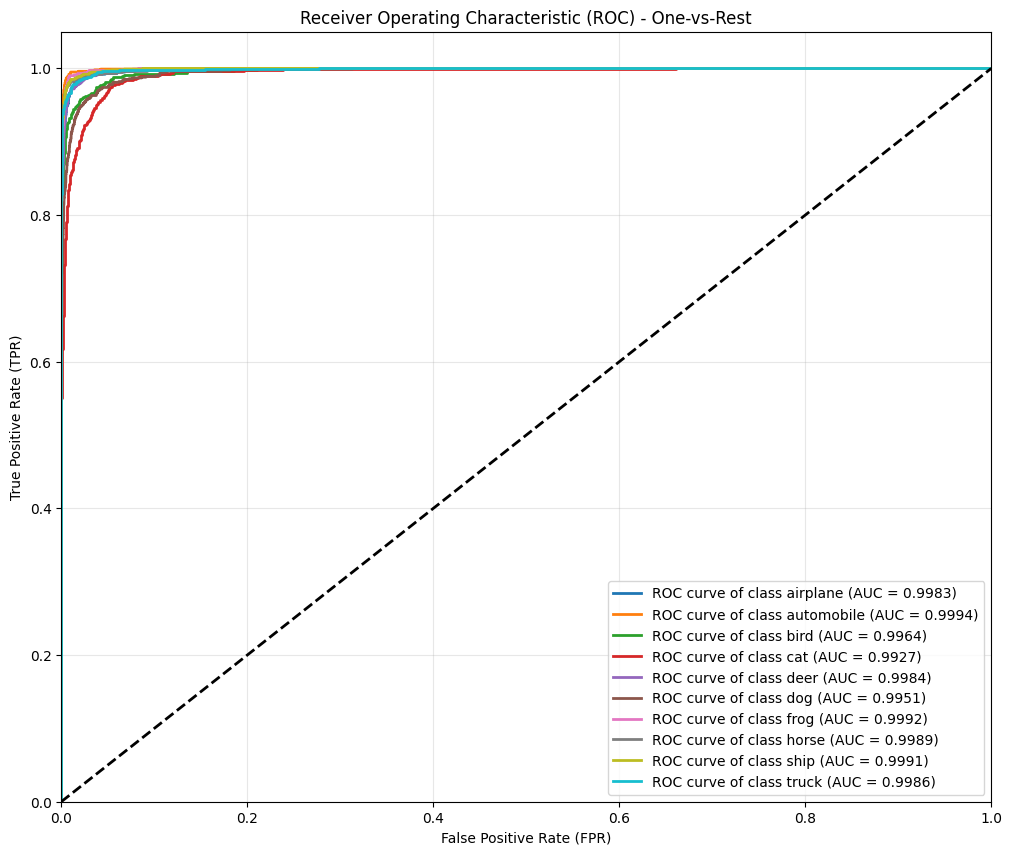

In [28]:
# 1. Gather prediction probabilities
model.eval()
y_probs = []
y_true = []

with torch.no_grad():
    for batch in test_loader:
        inputs = batch['pixel_values'].to(device)
        labels = batch['label'].to(device)

        # Forward pass
        outputs = model(inputs)
        # Apply softmax to get probabilities
        probs = F.softmax(outputs, dim=1)

        y_probs.extend(probs.cpu().numpy())
        y_true.extend(labels.cpu().numpy())

y_probs = np.array(y_probs)
y_true = np.array(y_true)

# 2. Binarize the labels for One-vs-Rest (OvR)
n_classes = len(class_labels)
y_true_bin = label_binarize(y_true, classes=range(n_classes))

# 3. Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# 4. Plot the ROC curves
plt.figure(figsize=(12, 10))
colors = plt.cm.get_cmap('tab10', n_classes)

for i, color in zip(range(n_classes), colors.colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC curve of class {class_labels[i]} (AUC = {roc_auc[i]:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) - One-vs-Rest')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

## Visualizing Hidden Units (Mechanistic Interpretability)

Let's peek inside the neural network! We can extract the raw learned weights (filters) of the very first convolutional layer (`model.conv1`).

This layer has 64 filters, each with a 3x3 pixel dimension and 3 color channels (RGB). By normalizing these weights into standard color values, we can visually see the foundational patterns (like edge detectors, color contrasts, and gradients) the model looks for before combining them into more complex shapes in deeper layers.

Shape of the filters: torch.Size([64, 3, 3, 3])


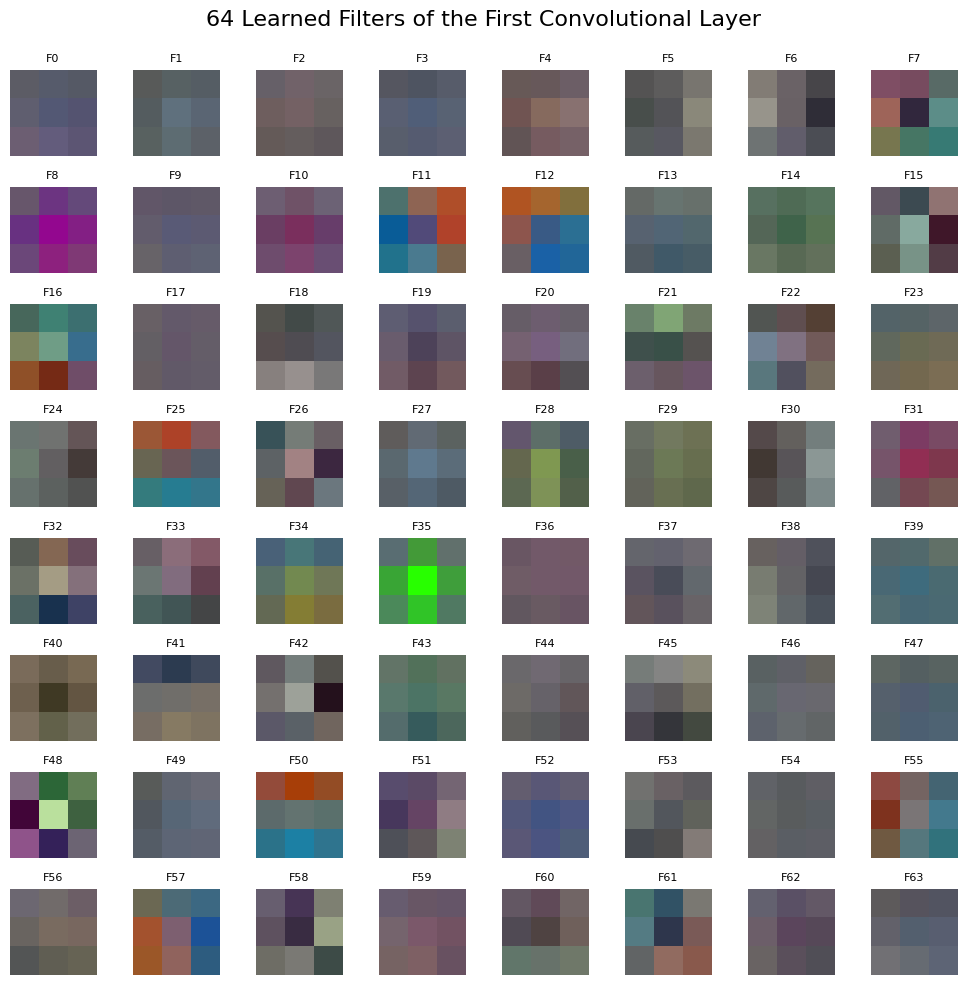

In [29]:
# Extract the weights from the first convolutional layer
filters = model.conv1.weight.data.cpu().clone()

# The shape is (64, 3, 3, 3) -> (out_channels, in_channels, height, width)
print(f"Shape of the filters: {filters.shape}")

# Normalize the weights to the [0, 1] range so we can display them as images
filters = filters - filters.min()
filters = filters / filters.max()

# Plot the 64 filters in an 8x8 grid
fig, axes = plt.subplots(8, 8, figsize=(10, 10))
axes = axes.flatten()

for i in range(len(filters)):
    # PyTorch tensors are (C, H, W). Matplotlib expects (H, W, C) for RGB images.
    filter_img = filters[i].numpy().transpose(1, 2, 0)

    axes[i].imshow(filter_img)
    axes[i].axis('off')
    axes[i].set_title(f'F{i}', fontsize=8)

plt.suptitle('64 Learned Filters of the First Convolutional Layer', fontsize=16)
plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()

## Feature Space Visualization (t-SNE)

To see how well our network separates the different classes in its internal representation, we can extract the high-dimensional features from the layer right before the final classifier (`avg_pool`).

Since these features exist in 512 dimensions, we use **t-SNE** to reduce them to 2 dimensions for visualization. A well-trained model will show distinct clusters for each class, demonstrating that it has learned to spatially separate images of different categories.

In [31]:
# 1. Extract Features using a Forward Hook
features = []
true_labels_tsne = []

def hook_fn(module, input, output):
    # Flatten the output from the avg_pool layer
    features.append(output.view(output.size(0), -1).cpu().numpy())

hook = model.avg_pool.register_forward_hook(hook_fn)

model.eval()
with torch.no_grad():
    # Using a subset of the test loader to keep t-SNE execution fast
    for i, batch in enumerate(test_loader):
        if i > 30: # ~2000 images
            break
        inputs = batch['pixel_values'].to(device)
        labels = batch['label']
        model(inputs)
        true_labels_tsne.extend(labels.numpy())

hook.remove()

features = np.concatenate(features, axis=0)
true_labels_tsne = np.array(true_labels_tsne)

print(f"Extracted features shape: {features.shape}")

Extracted features shape: (1984, 512)


Running t-SNE (this might take a few seconds)...


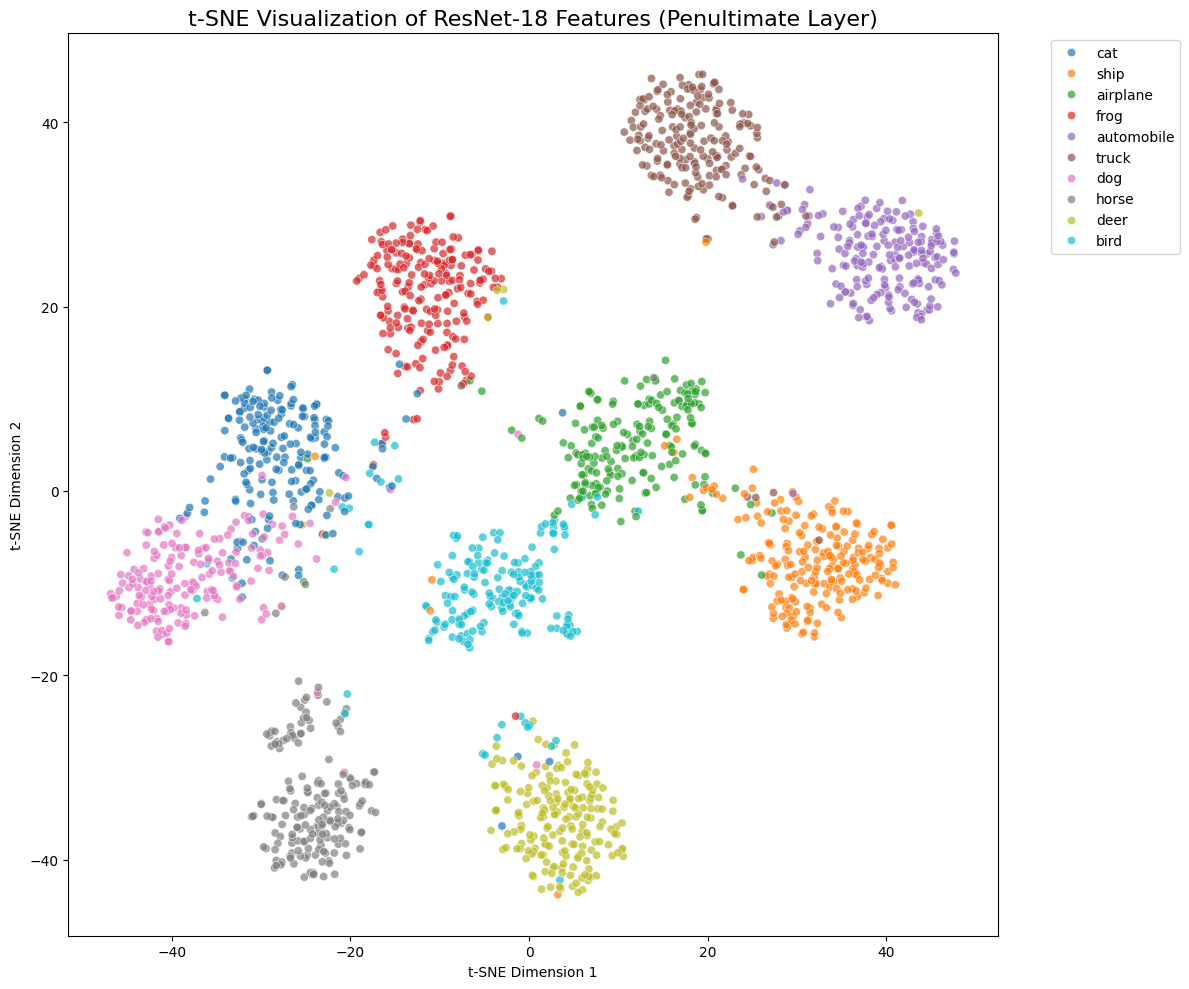

In [32]:
# 2. Run t-SNE Dimensionality Reduction
print("Running t-SNE (this might take a few seconds)...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
features_2d = tsne.fit_transform(features)

# 3. Plot the results
df_tsne = pd.DataFrame({
    'tsne_1': features_2d[:, 0],
    'tsne_2': features_2d[:, 1],
    'class': [class_labels[label] for label in true_labels_tsne]
})

plt.figure(figsize=(12, 10))
sns.scatterplot(
    x='tsne_1', y='tsne_2',
    hue='class',
    palette=sns.color_palette("tab10", 10),
    data=df_tsne,
    legend="full",
    alpha=0.7
)
plt.title('t-SNE Visualization of ResNet-18 Features (Penultimate Layer)', fontsize=16)
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Cleaning Notebook Metadata for GitHub Upload

This section provides a utility to clean up problematic metadata that Google Colab sometimes embeds in `.ipynb` files, which can cause rendering errors or `KeyError: 'state'` when viewed on GitHub. The script will read your current notebook, remove the offending metadata, and save a new, cleaned version.

In [ ]:
import json
import os

# --- IMPORTANT: Update this with your notebook's current filename ---
# You can find the filename at the top of your browser tab (e.g., 'MyAwesomeNotebook.ipynb')
notebook_filename = "YOUR_NOTEBOOK_NAME.ipynb"
# -------------------------------------------------------------------

output_filename = f"cleaned_{notebook_filename}"

# Make sure the notebook exists in the current directory (Colab's root /content/)
# If you've saved it elsewhere, update the path below.
if not os.path.exists(notebook_filename):
    print(f"Error: Notebook '{notebook_filename}' not found. Please ensure it's saved and the filename is correct.")
else:
    with open(notebook_filename, 'r', encoding='utf-8') as f:
        notebook_content = json.load(f)

    cleaned_cells = []
    for cell in notebook_content['cells']:
        if 'outputs' in cell:
            cleaned_outputs = []
            for output in cell['outputs']:
                # Remove problematic 'application/vnd.google.colaboratory.argvalues' metadata
                if output.get('output_type') == 'display_data' and \
                   'application/vnd.google.colaboratory.argvalues' in output.get('data', {}):
                    # Create a new output dictionary, excluding the problematic data key
                    new_output = {k: v for k, v in output.items() if k != 'data'}
                    # Copy other data types if they exist
                    if 'data' in output:
                        new_data = {k: v for k, v in output['data'].items() if k != 'application/vnd.google.colaboratory.argvalues'}
                        if new_data: # Only add 'data' key if there's actual data left
                            new_output['data'] = new_data

                    if new_output.get('output_type') == 'display_data' and not new_output.get('data'):
                        # If it was only argvalues, and now data is empty, skip this output entirely
                        continue
                    cleaned_outputs.append(new_output)
                else:
                    cleaned_outputs.append(output)
            cell['outputs'] = cleaned_outputs
        cleaned_cells.append(cell)

    notebook_content['cells'] = cleaned_cells

    with open(output_filename, 'w', encoding='utf-8') as f:
        json.dump(notebook_content, f, indent=1) # Use indent for readability on GitHub

    print(f"Cleaned notebook saved as '{output_filename}'. You can now download this file and upload it to GitHub.")